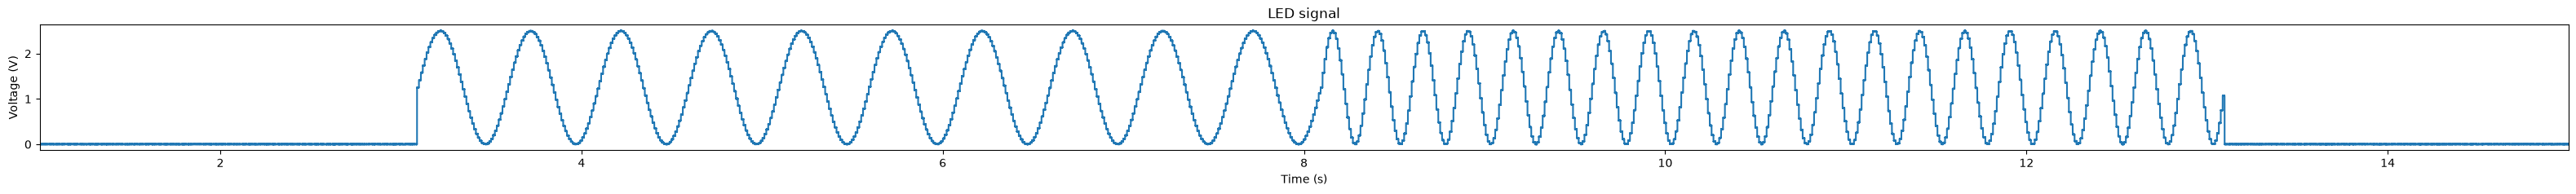

In [ ]:
# Plotting LED signal from NI-DAQ binary data
import numpy as np

def read_meta(meta_path):
    meta = {}
    with open(meta_path, 'r') as f:
        for line in f:
            key, val = line.strip().split('=', 1)
            meta[key] = val
    return meta

# Load meta
meta = read_meta('20260622_test_g0_t0.nidq.meta')
fs = float(meta['niSampRate'])        # sample rate in Hz (e.g. 11574.1)
n_chans = int(meta['nSavedChans'])    # number of channels saved

# Load binary
raw = np.fromfile('20260622_test_g0_t0.nidq.bin', dtype=np.int16)
data = raw.reshape(-1, n_chans)       # shape: (n_samples, n_chans)

# Voltage conversion
scale = 5.0 / 32768                   # for [-5, 5]V range
led = data[:, 0] * scale              # XA0 = column 0, in volts

# Time vector in seconds
t = np.arange(len(led)) / fs         # seconds

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(40, 2))
plt.plot(t, led)
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.title('LED signal')
plt.xlim(1, 15)
plt.show()

In [ ]:
# Syncing LED signal with spike times with 1Hz waveform:
import numpy as np

# ── Helper functions ────────────────────────────────────────────────────────
def read_meta(path):
    meta = {}
    with open(path, 'r') as f:
        for line in f:
            if '=' in line:
                k, v = line.strip().split('=', 1)
                meta[k] = v
    return meta

def rising_edges(sig):
    """Returns sample indices where signal goes 0 → 1."""
    return np.where(np.diff(sig.astype(np.int16)) > 0)[0]

# ── Load NIDQ (LED + sync) ──────────────────────────────────────────────────
nidq_meta = read_meta('run_g0_t0.nidq.meta')
nidq_fs   = float(nidq_meta['niSampRate'])
nidq_nc   = int(nidq_meta['nSavedChans'])

nidq     = np.fromfile('run_g0_t0.nidq.bin', dtype=np.int16).reshape(-1, nidq_nc)
led      = nidq[:, 0] * (5.0 / 32768)       # XA0 → volts
sync_ni  = (nidq[:, -1] & 1).astype(np.int8)  # XD0 bit 0 → sync pulse

# ── Load IMEC sync channel only (memory efficient) ─────────────────────────
imec_meta = read_meta('run_g0_t0.imec0.ap.meta')
imec_fs   = float(imec_meta['imSampRate'])
imec_nc   = int(imec_meta['nSavedChans'])

imec_mm  = np.memmap('run_g0_t0.imec0.ap.bin', dtype=np.int16, mode='r').reshape(-1, imec_nc)
sy       = imec_mm[:, -1]                           # last channel = SY
sync_im  = ((sy & (1 << 6)) > 0).astype(np.int8)   # bit 6 = SMA TRIG input

# ── Find sync edges in both streams ────────────────────────────────────────
edges_ni = rising_edges(sync_ni)   # samples in NIDQ clock
edges_im = rising_edges(sync_im)   # samples in IMEC clock

print(f"Sync edges found — NIDQ: {len(edges_ni)},  IMEC: {len(edges_im)}")

# Trim to matching count (should be equal)
n       = min(len(edges_ni), len(edges_im))
t_ni    = edges_ni[:n] / nidq_fs   # NIDQ sync times in seconds
t_im    = edges_im[:n] / imec_fs   # IMEC sync times in seconds

# ── Map NIDQ timebase → IMEC timebase ──────────────────────────────────────
t_led_nidq = np.arange(len(led)) / nidq_fs          # LED time in NIDQ seconds
t_led_imec = np.interp(t_led_nidq, t_ni, t_im)      # LED time in IMEC seconds

# ── Now you can compare LED with spike times ────────────────────────────────
# spike_times is in IMEC seconds (from Kilosort/etc.)
# t_led_imec is on the same clock
# Example: find LED onset times in IMEC timebase
led_thresh = 0.5   # volts threshold for LED ON
led_on     = (led > led_thresh).astype(np.int8)
led_onsets_nidq = rising_edges(led_on)
led_onsets_imec = np.interp(led_onsets_nidq / nidq_fs, t_ni, t_im)  # in IMEC seconds

print(f"LED onsets (IMEC timebase): {led_onsets_imec}")